In [10]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [11]:
# The yahoo api is payed so lets instead use another free api to get the stock data i used stooq, you just need a free apikey from https://stooq.com/q/d/?s=aapl.us
APIKEY = "COa2gJQuK0X1c4DihNGzTxIFH8pf3Md7"

def get_aapl_prices():
    url = f"https://stooq.com/q/d/l/?s=aapl.us&i=d&apikey={APIKEY}"
    data = pd.read_csv(url)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values("Date")
    return data.set_index("Date")["Close"]

#set the stock prices we got equal to a variable
all_prices = get_aapl_prices()

#select only the prices for the timeframe which was asked for the project
prices = all_prices.loc["2020-01-01":"2026-04-30"]

#lets see the amount of loaded prices from the start date to the end date
print("Loaded", len(prices), "daily prices from", prices.index[0].date(), "to", prices.index[-1].date())


Loaded 1590 daily prices from 2020-01-02 to 2026-04-30


Missing prices: 0
Missing log returns: 0


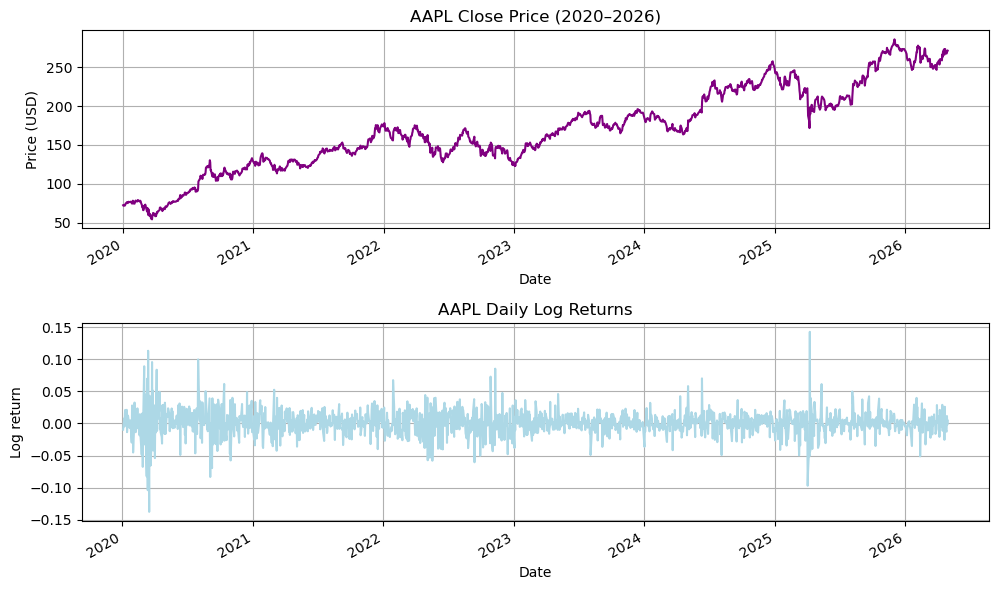

In [12]:
# compute daily log returns so we can plot them next to the price we do this because the binomial tree is defined on the log returns
# to do this e need to take the log of the price divded by the price of the previous day which de do with a shift
log_returns = np.log(prices / prices.shift(1)).dropna() # The first row is NA becuse there is no S0_t-1 so we have a dropna() to remove this one problematic row

# Even before printing i want to make sure that there are no missing values because I've had difficulty in the past with this
print("Missing prices:", prices.isna().sum())
print("Missing log returns:", log_returns.isna().sum())

#Lets make a plot for apple stock closing prices and the log returns
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020–2026)", color="purple")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="lightblue")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()


In [13]:
# Lets start by determining the parameters which were stated in the assignment

# Maturity
T  = 0.5
# Number of binomial periods
n  = 25
#change in time for each period
dt = T / n
# Risk-free rate per annum
r  = 0.01
# Initial stock price on the first day which was specified by the timeframe in the assignment (last day of the trading, first day of the simulation of option trading)
S0 = all_prices.loc["2026-04-28"]

# Now we need to define geometric Brownian Motion:

# The whole setup assumes that dSt​=μSt​dt+σSt​dWt which if you apply ito's lemma is the log price d(lnSt​)=(μ−21​σ2)dt+σdW

#the up (u) and down (d) factors and to do this we need the sigma daily volitity as described we can find an estimate by using our historical price data

#we compute the daily volitility 
sigma_daily = log_returns.std()

#then we need to rescale the daily volatility into the a per year quantity because this si the convetnion the model uses 
# assuming iid variance scales linearly with time so 250 days of variance is 250 * daily variance but volatilituy is the square root of variance
# the 250 per year was given by the assignment and is around the average number of trading days per year
sigma = sigma_daily * np.sqrt(250) 

# Now we compute u and d using the formula which is derived from matching bionomial tree to the brownian motion 

# e ^ sigma * sqrt(dt)
u = np.exp(sigma * np.sqrt(dt))
# e ^ -sigma * sqrt(dt) or 1/u
d = np.exp(-sigma * np.sqrt(dt))
#the formulas choose u and d so that one step of the binomial tree behaves statistically like one step of the continuous GMB model


# the probability of an up move was given by the assignment as 1/2
p = 0.5

# Before we move on lets so a sanity check to make sure all the variables look like something we would expect

print(f"T            = {T}")
print(f"n            = {n}")
print(f"r            = {r}")
print(f"S_0          = {S0:.2f} USD")
print(f"sigma_daily  = {sigma_daily:.6f}")
print(f"sigma_annual = {sigma:.6f}")
print(f"u            = {u:.6f}")
print(f"d            = {d:.6f}")
print(f"p            = {p}")


T            = 0.5
n            = 25
r            = 0.01
S_0          = 270.71 USD
sigma_daily  = 0.019784
sigma_annual = 0.312816
u            = 1.045232
d            = 0.956725
p            = 0.5


## Task (iv) — Risk-Neutral Probability

The brief gave us the **physical** probability $p = 1/2$ — how often nature actually rolls "up" vs "down". But we cannot price the option with $p$, because two people can disagree about $p$ yet they must agree on the price of the option (otherwise one can arbitrage the other). So the option price has to depend only on quantities everyone observes: $S_0, u, d, r$.

The **risk-neutral probability** $q$ is a synthetic probability chosen so that, under it, the discounted stock price is a martingale:

$$S_t = e^{-r\Delta t}\,\mathbb{E}^Q[S_{t+\Delta t}\mid\mathcal{F}_t]$$

Substituting the binomial dynamics ($S_{t+\Delta t} = S_t u$ with prob $q$, or $S_t d$ with prob $1-q$) and solving for $q$:

$$q = \frac{e^{r\Delta t} - d}{u - d}$$

The **Fundamental Theorem of Asset Pricing** (Chapter 2, slide 48) then tells us that the arbitrage-free price of any derivative is its discounted expected payoff under $Q$:

$$V_0 = e^{-rT}\,\mathbb{E}^Q[\text{payoff at }T]$$

That's the formula we'll apply by backward induction in Task (v). Two extra quantities we set up here:
- `disc = exp(-r·dt)` — one-period discount factor (saves recomputing $e^{-r\Delta t}$ at every node)
- `assert 0 < q < 1` — sanity check; if $q$ falls outside $(0,1)$ the no-arbitrage condition $d < e^{r\Delta t} < u$ has been violated.

In [14]:
# We have to use a probability measure for the option other than p because although p is how nature will move up and down people have different opintions on what p is and to properly price an option we need to know what the expected
# non-arbitrage value is inorder to do this we cant rely on anything subjective so we must make a probability measure which is derived from observables that everyone can see in this case r,dt, and sigma
#sigma is included in the formula through the derivations of u and d 
q = (np.exp(r * dt) - d) / (u - d)

# if q is outside (0,1) the model would admit to arbitrage and an assumption of modern markets is so arbitradge so lets make a sanity check on q to make sure everything is fine if something is wrong the program will crash
assert 0 < q < 1, f"q = {q:.4f} outside (0,1) — model admits arbitrage!"

print(f"q = {q:.6f}")
print(f"No-arbitrage check 0 < q < 1  → OK")


q = 0.491202
No-arbitrage check 0 < q < 1  → OK


In [15]:
# now is time for the fun part we have to define a function which applies the paramenters of 
def price_floating_asian(S0, sigma, r, T, n):
    # the first step is to define our varibales from the value of the given parameters
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = np.exp(-sigma * np.sqrt(dt))
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    #the next step is to create the structure of our tree and every possible outcome which is done using states where each possible outcome gives birth to two child outcomes which are a summing cumulative product of S0 and u and d which we will then map values to in a later function
    #The tree need the shape list[dict[set]]:
        #state[t] is the dictionary at each time point
        #states[t][j] is the set of all reachable cumulative sums C at not (t,j)
    # we need to make a nexted path because the option is path dependent and we need to teen them seperate without having the number of of dictionaries explode which would be bad for our computing budget
    states = []
    
    # the tree has n transitions but n+1 time points: t = 0, dt, 2dt, ..., n·dt = T and we need a dict at every time point, so range is n+1,  don't forget t=0!
    for t in range(n + 1): 
        #for each of the steps we create a dictionary which is keyed by the number of up moves so far
        #values get filled by foward pass
        states.append({})
    #We also need to set the cumulative sum to S0 since only one price is recorded at t=0
    states[0][0] = {S0}

# now we need to define what happens at each time step above we made the time points but now we need what happens in the transition
# for every time t we need to spawn two children one with up move values and one with down move values
#Things to consider
    # we have to make sure to only read from t and only write into t+1 so we dont mess up any past nodes
    # use range(n) because here we are doing the transitions not the time points 
    for t in range(n):
        #now we have to loop over every up move so we iterates h through every kety strored in states[t]
        for j in list(states[t].keys()):
            #now on each iteration we set one specific up count value 0, then 1, then 2, ect. through states[t][j] which is a set containing every distinct cumulative sum through all paths that point to this state node
            c_set = states[t][j] #specified as value to avoid repeated hashing and for readability

            # we now have to compute the current stock price at each j in each t to do that we just nultiply S0 by the number of up moves and the up move value and the number of down moves and the down move value this value is path independent
            S_now = S0 * (u ** j) * (d ** (t - j))

            #we are now inside the t and j loop so now we are at a specific node where c_set is the set of all cummulative sums recorded at that node
            # in c_set are elements containing the path history that arrived at (t,j) on each pass c must be calculated as one specific float 
            for C in c_set:
                # now we need if j+1 (childs up count) is not already a key in states[t+1] (the dict for the next time level) then we need to cteate a new empty set at that key to store the C values 
                if (j + 1) not in states[t + 1]:
                    states[t + 1][j + 1] = set()
                #then we add the value of the the up move to the C value for the next time frame
                states[t + 1][j + 1].add(C + S_now * u)
                # We do the same thing for the down count but we have to remember not to change the up count so NO j+1 on the index and to use d instead of u
                if j not in states[t + 1]:
                    states[t + 1][j] = set()
                states[t + 1][j].add(C + S_now * d)

    # Now that we calulcuated the states we need to calculate the values
    values = []

    # we again make a dictionary at each time point +1
    for t in range(n + 1):
        values.append({})

    # now we acess each last time level n which have key values of j which includes all j values of (0->n) (all up moves, all down moves, and everything inbetweem)
    for j in states[n]:
        #then we compute the terminal value at the right most part of the tree from top to botoom and fill values for all S terminals at that time step n this is not S-now but S_t becuase is the terminal price at maturity
        S_T = S0 * (u ** j) * (d ** (n - j))
        #next we make an empty dictionary at this slot in values to map the cummulative sums to option values where each c is a key  and each payofff will be the value
        values[n][j] = {}

        #now we loop over every cumulative sum C which is one path history that reached (n,j)
        for C in states[n][j]:
            #now we can calculate the maturity at payooff for each node using the floating-strike asian call payoff formula
            payoff = S_T - C / (n + 1) #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE

            #make sure negative payoffs are zero because call options can never have a negative payoff because you simply would not exercise option if you lose money jsut take max of payoff or 0
            payoff = max(payoff,0.0)
            #for each time frame acess each j key and then set the value equal to the payoff 
            values[n][j][C] = payoff

# So far we've built the full grid of reachable augmented states (t, j, C) in the
# forward pass and pinned down the option's payoff at every terminal node (t=n).
# All that's left is backward induction: take those terminal payoffs and roll them
# back through the tree, at each node computing the discounted risk-neutral
# expected value of its two children, until we collapse everything down to a single
# number at (t=0, j=0, C=S0) — the arbitrage-free option price today.

    # we start at n-1 for backword induction because n was already filled bye the termila payoffs and go all the way to 0, you must include -1 as the stop value because python does not include the stop value in the formula, the step must be -1 because we are counting backwards
    for t in range(n - 1, -1, -1):
        # fro every up count j at this time level we process every node 
        for j in states[t]:
            #compute the current stcok price at node which is path independnet so its outside the C loop
            S_now = S0 * (u ** j) * (d ** (t - j))
            #we now make an empty dictionary at this node to holde the C->V mappings
            values[t][j] = {}
            #now we loop through each c which is one sepciifc path history to get the value of the up child and the down child  because to compute the option value we need to know these two values which are filled in from the pervious loop
            for C in states[t][j]:
                #we have to get the values by accessing the dict at the next time level up, get the childs up count which is one more than the parents and inside that dict look up the entry for the childs cumulative sum
                #the childs cumulative sum is the cumalitive sum of the parent plus the price now times u or d respectivally
                V_up = values[t + 1][j + 1][C + S_now * u] 
                V_dn = values[t + 1][j    ][C + S_now * d]
                #now we have to use the formula that actually computes the option value at this node — the discounted risk-neutral expectation of the two children
                #V_t = disc * (q * V_up + (1-q) * V_dn) — derived from the replication argument
                #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE
                # we then use the value the formula gave out and index it to the current time frame at the correct j count  in the slot for the cummulative sum
                values[t][j][C] = disc * (q * V_up + (1 - q) * V_dn)

    # we then have to return the abritrage free price of the option today which is just the first node of the backward inductuon and then we access the key for the first original parent value S0
    return values[0][0][S0] 

In [9]:
%%time
# now that we defined the function lets actually run it and also see how long it takes.

price_binomial = price_floating_asian(S0, sigma, r, T, n)

print(f"Binomial price at t=0 : {price_binomial:.4f} USD")


Binomial price at t=0 : 14.0418 USD
CPU times: user 2.07 s, sys: 98.5 ms, total: 2.17 s
Wall time: 2.21 s


In [ ]:
# Now that we have applied backward induction we have to run a robustness check to ensure 

r_grid     = [0.0, 0.005, 0.01, 0.015, 0.02]
sigma_grid = [sigma * 0.8, sigma * 0.9, sigma, sigma * 1.1, sigma * 1.2]

results = pd.DataFrame(
    index=[f"{s:.4f}" for s in sigma_grid],
    columns=[f"{rr:.2%}" for rr in r_grid],
    dtype=float,
)
results.index.name   = "sigma"
results.columns.name = "r"

for s_val in sigma_grid:
    for r_val in r_grid:
        price = price_floating_asian(S0, s_val, r_val, T, n)
        results.loc[f"{s_val:.4f}", f"{r_val:.2%}"] = price

print("Floating-strike Asian call price (USD):")
print(results.round(4).to_string())

Floating-strike Asian call price (USD):
r         0.00%    0.50%    1.00%    1.50%    2.00%
sigma                                              
0.2505  10.8681  11.0271  11.1874  11.3489  11.5118
0.2818  12.2241  12.3818  12.5407  12.7008  12.8619
0.3131  13.5791  13.7357  13.8933  14.0518  14.2114
0.3444  14.9332  15.0886  15.2449  15.4020  15.5601
0.3757  16.2862  16.4404  16.5954  16.7512  16.9078


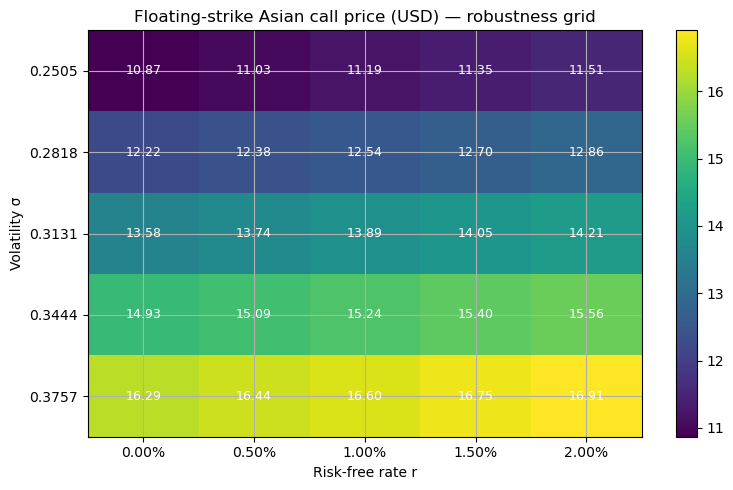

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(results.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(r_grid)))
ax.set_xticklabels([f"{rr:.2%}" for rr in r_grid])
ax.set_yticks(range(len(sigma_grid)))
ax.set_yticklabels([f"{s:.4f}" for s in sigma_grid])
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Volatility σ")
ax.set_title("Floating-strike Asian call price (USD) — robustness grid")
for i in range(len(sigma_grid)):
    for j in range(len(r_grid)):
        ax.text(j, i, f"{results.values[i, j]:.2f}",
                ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [9]:
def monte_carlo_floating_asian(S0, sigma, r, T, n, n_sims=200_000, seed=42):
    rng = np.random.default_rng(seed)
    dt  = T / n

    Z = rng.standard_normal((n_sims, n))

    log_ret = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

    log_paths = np.concatenate(
        [np.full((n_sims, 1), np.log(S0)),
         np.log(S0) + np.cumsum(log_ret, axis=1)],
        axis=1,
    )
    paths = np.exp(log_paths)

    avg    = paths.mean(axis=1)
    payoff = np.maximum(paths[:, -1] - avg, 0.0)
    price  = np.exp(-r * T) * payoff.mean()
    se     = np.exp(-r * T) * payoff.std() / np.sqrt(n_sims)
    return price, se

mc_price, mc_se = monte_carlo_floating_asian(S0, sigma, r, T, n)
ci_lo = mc_price - 1.96 * mc_se
ci_hi = mc_price + 1.96 * mc_se

print(f"Monte Carlo (200k paths) : {mc_price:.4f} USD")
print(f"  95% CI               : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Binomial price         : {price_binomial:.4f} USD")
print(f"Absolute difference    : {abs(mc_price - price_binomial):.4f} USD")

Monte Carlo (200k paths) : 13.9131 USD
  95% CI               : [13.8118, 14.0144]
Binomial price         : 13.8933 USD
Absolute difference    : 0.0199 USD


In [10]:
m1 = np.exp(r * dt)
m2 = q * u**2 + (1 - q) * d**2

ES = np.zeros(n + 1)
for t in range(n + 1):
    ES[t] = S0 * m1**t

cov_mat = np.zeros((n + 1, n + 1))
for s in range(n + 1):
    for t in range(n + 1):
        E_SsSt        = S0**2 * m2**min(s, t) * m1**abs(s - t)
        cov_mat[s, t] = E_SsSt - ES[s] * ES[t]

sum_ES = 0.0
for t in range(n + 1):
    sum_ES += ES[t]
E_Dn = ES[n] - sum_ES / (n + 1)

Var_Sn = cov_mat[n, n]

cov_Sn_sum = 0.0
for t in range(n + 1):
    cov_Sn_sum += cov_mat[n, t]

cov_total = 0.0
for s in range(n + 1):
    for t in range(n + 1):
        cov_total += cov_mat[s, t]

Var_Dn = Var_Sn - 2/(n+1) * cov_Sn_sum + cov_total / (n + 1)**2
sd_Dn  = np.sqrt(Var_Dn)

ratio        = E_Dn / sd_Dn
price_normal = np.exp(-r * T) * (E_Dn * norm.cdf(ratio) + sd_Dn * norm.pdf(ratio))

print(f"m_1                        = {m1:.6f}")
print(f"m_2                        = {m2:.6f}")
print(f"mu_D  (E[D_n])             = {E_Dn:.4f} USD")
print(f"sd_D  (sqrt(Var[D_n]))     = {sd_Dn:.4f} USD")
print()
print(f"Normal-approximation price = {price_normal:.4f} USD")
print(f"Binomial price             = {price_binomial:.4f} USD")
print(f"Absolute difference        = {price_normal - price_binomial:+.4f} USD")
print(f"Relative difference        = {(price_normal - price_binomial)/price_binomial:+.2%}")

m_1                        = 1.000200
m_2                        = 1.002361
mu_D  (E[D_n])             = 0.6712 USD
sd_D  (sqrt(Var[D_n]))     = 34.6769 USD

Normal-approximation price = 14.1016 USD
Binomial price             = 13.8933 USD
Absolute difference        = +0.2083 USD
Relative difference        = +1.50%


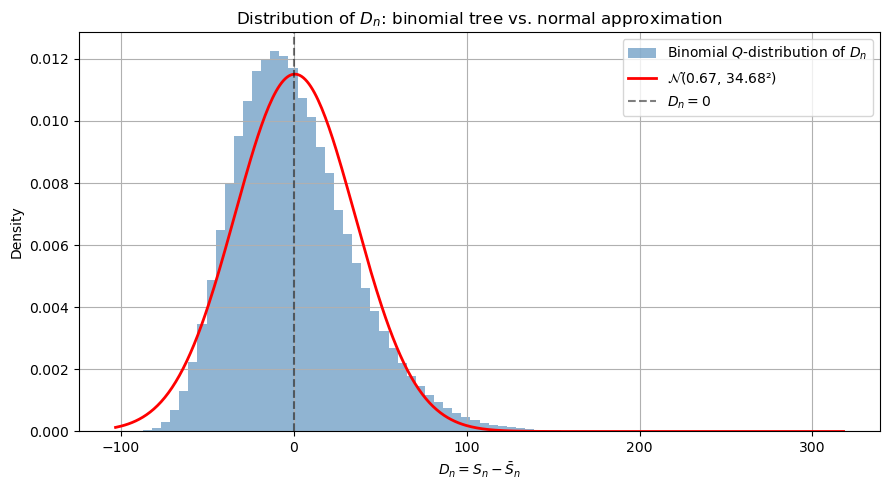

In [11]:
prob_states = []
for t in range(n + 1):
    prob_states.append({})
prob_states[0][0] = {S0: 1.0}

for t in range(n):
    for j in list(prob_states[t].keys()):
        c_dict = prob_states[t][j]
        S_now  = S0 * (u**j) * (d**(t - j))
        for C in c_dict:
            prob = c_dict[C]
            if (j + 1) not in prob_states[t + 1]:
                prob_states[t + 1][j + 1] = {}
            new_C_up = C + S_now * u
            if new_C_up in prob_states[t + 1][j + 1]:
                prob_states[t + 1][j + 1][new_C_up] += prob * q
            else:
                prob_states[t + 1][j + 1][new_C_up] = prob * q
            if j not in prob_states[t + 1]:
                prob_states[t + 1][j] = {}
            new_C_dn = C + S_now * d
            if new_C_dn in prob_states[t + 1][j]:
                prob_states[t + 1][j][new_C_dn] += prob * (1 - q)
            else:
                prob_states[t + 1][j][new_C_dn] = prob * (1 - q)

Dn_values = []
Dn_probs  = []
for j in prob_states[n]:
    S_T = S0 * (u**j) * (d**(n - j))
    for C in prob_states[n][j]:
        Dn_values.append(S_T - C / (n + 1))
        Dn_probs.append(prob_states[n][j][C])
Dn_values = np.array(Dn_values)
Dn_probs  = np.array(Dn_probs)

assert abs(Dn_probs.sum() - 1.0) < 1e-9, "Q-probabilities must sum to 1"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(Dn_values, bins=80, weights=Dn_probs, density=True,
        alpha=0.6, color="steelblue", label=r"Binomial $Q$-distribution of $D_n$")
xx = np.linspace(Dn_values.min(), Dn_values.max(), 400)
ax.plot(xx, norm.pdf(xx, loc=E_Dn, scale=sd_Dn), "r-", lw=2,
        label=r"$\mathcal{N}$" + f"({E_Dn:.2f}, {sd_Dn:.2f}²)")
ax.axvline(0, color="k", linestyle="--", alpha=0.5, label=r"$D_n = 0$")
ax.set_xlabel(r"$D_n = S_n - \bar{S}_n$")
ax.set_ylabel("Density")
ax.set_title(r"Distribution of $D_n$: binomial tree vs. normal approximation")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print(f"  S_0 (2026-04-28)     : {S0:.2f} USD")
print(f"  sigma (annualised)   : {sigma:.4f}")
print(f"  T = {T}  n = {n}  r = {r:.1%}")
print("  " + "-"*56)
print(f"  Binomial price (exact)    = {price_binomial:.4f} USD")
print(f"  Monte Carlo  (200k paths) = {mc_price:.4f} USD  (±{1.96*mc_se:.4f})")
print(f"  Normal approximation      = {price_normal:.4f} USD")
print(f"  Relative diff (norm vs bin) = {(price_normal-price_binomial)/price_binomial:+.2%}")
print("=" * 60)
